In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample data (1).xlsx to Sample data (1).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("Sample data (1).xlsx")

In [ ]:
#Explore the datset
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount Band        647 non-null    object        
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9    Sales               700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month Number         700 non-null  

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


In [ ]:
# Checking missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64


In [ ]:
# Filling missing values

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64


In [ ]:
# Checking duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Removing duplicates

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (700, 16)


In [ ]:
# Converting date columns if present

for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col], errors="coerce")

df.dtypes

,0
Segment,object
Country,object
Product,object
Discount Band,object
Units Sold,float64
Manufacturing Price,int64
Sale Price,int64
Gross Sales,float64
Discounts,float64
Sales,float64


In [ ]:
# Checking unique values

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Segment: 5 unique values
Country: 5 unique values
Product: 6 unique values
Discount Band: 3 unique values
Units Sold: 510 unique values
Manufacturing Price: 6 unique values
Sale Price: 7 unique values
Gross Sales: 550 unique values
Discounts: 515 unique values
 Sales: 559 unique values
COGS: 545 unique values
Profit: 557 unique values
Date: 16 unique values
Month Number: 12 unique values
Month Name: 12 unique values
Year: 2 unique values


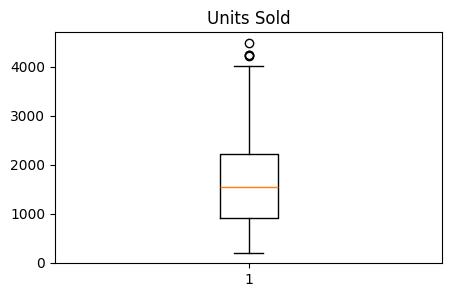

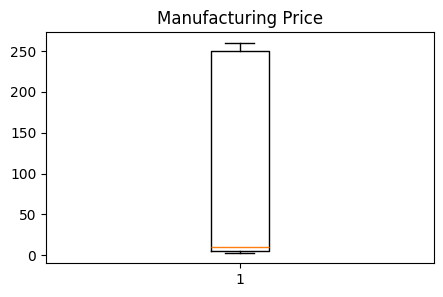

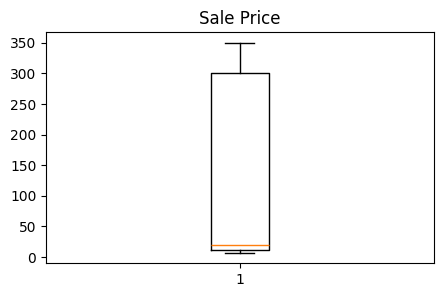

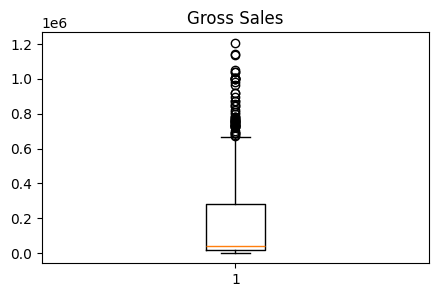

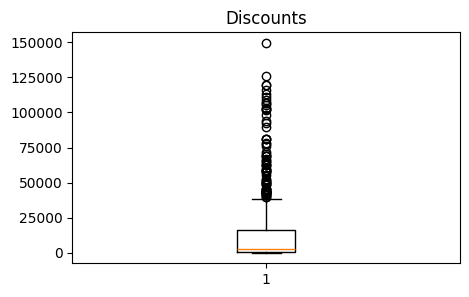

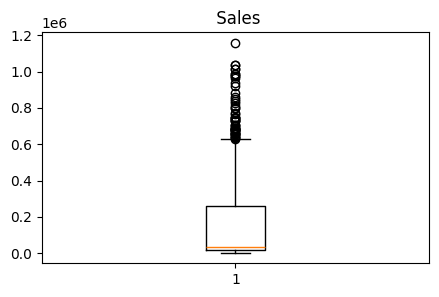

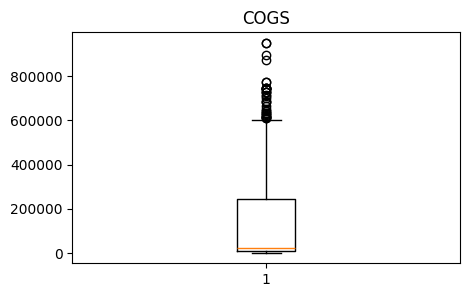

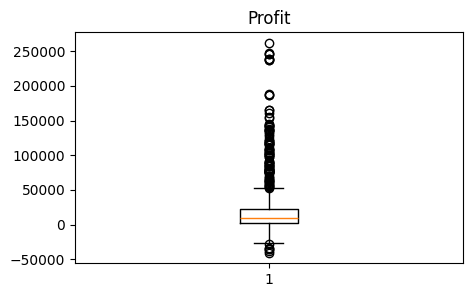

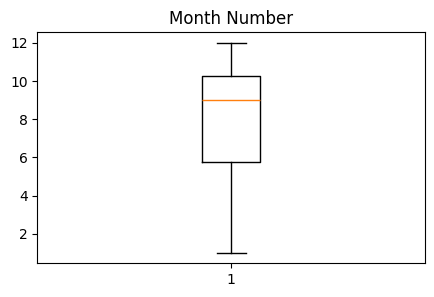

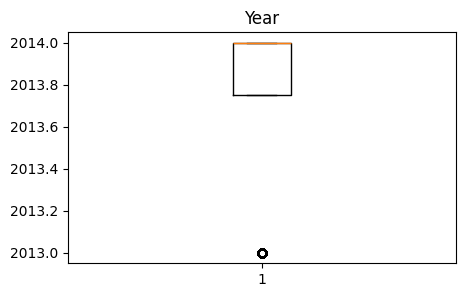

In [ ]:
# Boxplots for numeric columns

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [ ]:
# Removing outliers using the IQR method

clean_df = df.copy()

for col in numeric_cols:

    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

print("Final Shape:", clean_df.shape)

Final Shape: (399, 16)


In [ ]:
# Final dataset summary

clean_df.info()

clean_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 399 entries, 100 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              399 non-null    object        
 1   Country              399 non-null    object        
 2   Product              399 non-null    object        
 3   Discount Band        399 non-null    object        
 4   Units Sold           399 non-null    float64       
 5   Manufacturing Price  399 non-null    int64         
 6   Sale Price           399 non-null    int64         
 7   Gross Sales          399 non-null    float64       
 8   Discounts            399 non-null    float64       
 9    Sales               399 non-null    float64       
 10  COGS                 399 non-null    float64       
 11  Profit               399 non-null    float64       
 12  Date                 399 non-null    datetime64[ns]
 13  Month Number         399 non-null    i

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399,399.000000,399.000000
mean,1594.006266,91.478697,14.621554,21761.884712,1628.388947,20133.495764,11569.743108,8563.752657,2014-04-27 14:22:33.383458560,7.954887,2013.741855
min,218.000000,3.000000,7.000000,1799.000000,0.000000,1655.080000,918.000000,-2557.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,913.000000,5.000000,12.000000,10612.500000,405.145000,9824.485000,5386.500000,2998.400000,2013-12-01 00:00:00,6.000000,2013.000000
50%,1565.000000,10.000000,15.000000,19460.000000,1132.800000,18035.920000,8742.000000,7146.300000,2014-05-01 00:00:00,9.000000,2014.000000
75%,2244.500000,250.000000,20.000000,30660.000000,2330.580000,28709.475000,16162.500000,12658.800000,2014-09-16 00:00:00,10.500000,2014.000000
max,3997.500000,260.000000,125.000000,59962.500000,7795.125000,55071.200000,41400.000000,27459.900000,2014-12-01 00:00:00,12.000000,2014.000000
std,836.518051,107.534003,12.067217,13636.044885,1608.658915,12562.360252,8601.104710,6624.390720,NaN,3.354734,0.438164


In [ ]:
# Saving the cleaned dataset

clean_df.to_excel("Cleaned_Data.xlsx", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
# Download the cleaned dataset

files.download("Cleaned_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>